In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.11.0+cu128
True


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [13]:
from torchvision import datasets, transforms
import torch

# Load with ONLY ToTensor (pixels scaled to [0,1], no normalization yet)
raw_transform = transforms.Compose([transforms.ToTensor()])
raw_train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=raw_transform)

# Stack all images into one big tensor to compute stats
# raw_train_dataset.data has raw pixel values (0-255) as a tensor already,
# but let's do it "properly" through the transform pipeline to match what the model sees

loader = DataLoader(raw_train_dataset, batch_size=len(raw_train_dataset), shuffle=False)
all_images, _ = next(iter(loader))   # shape: [60000, 1, 28, 28]

computed_mean = all_images.mean().item()
computed_std = all_images.std().item()

print(f"Computed mean: {computed_mean:.4f}")
print(f"Computed std:  {computed_std:.4f}")

Computed mean: 0.1307
Computed std:  0.3081


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),              # converts image to tensor, scales pixels to [0,1]
    transforms.Normalize((computed_mean,), (computed_std,))  # standard MNIST mean/std
])

train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.67MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.24MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.9MB/s]

Train samples: 60000
Test samples: 10000


In [ ]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()               # 28x28 -> 784
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)              # 10 output classes (digits 0-9)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)                             # no softmax here; CrossEntropyLoss handles it
        return x

model = MLP().to(device)
print(model)

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
num_epochs = 5
loss_history = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/5], Loss: 0.0339
Epoch [2/5], Loss: 0.0298
Epoch [3/5], Loss: 0.0264
Epoch [4/5], Loss: 0.0210
Epoch [5/5], Loss: 0.0199


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test accuracy: {accuracy:.2f}%")

Test accuracy: 97.89%


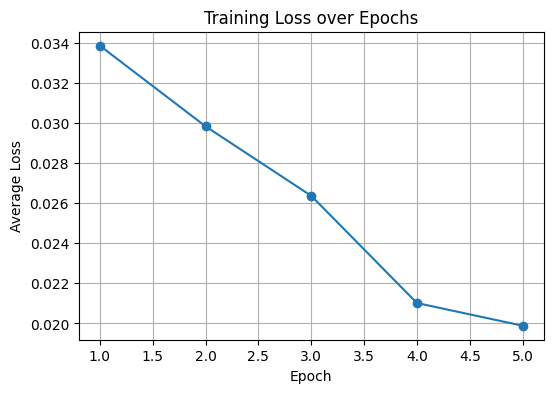

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(range(1, num_epochs+1), loss_history, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Training Loss over Epochs")
plt.grid(True)
plt.show()

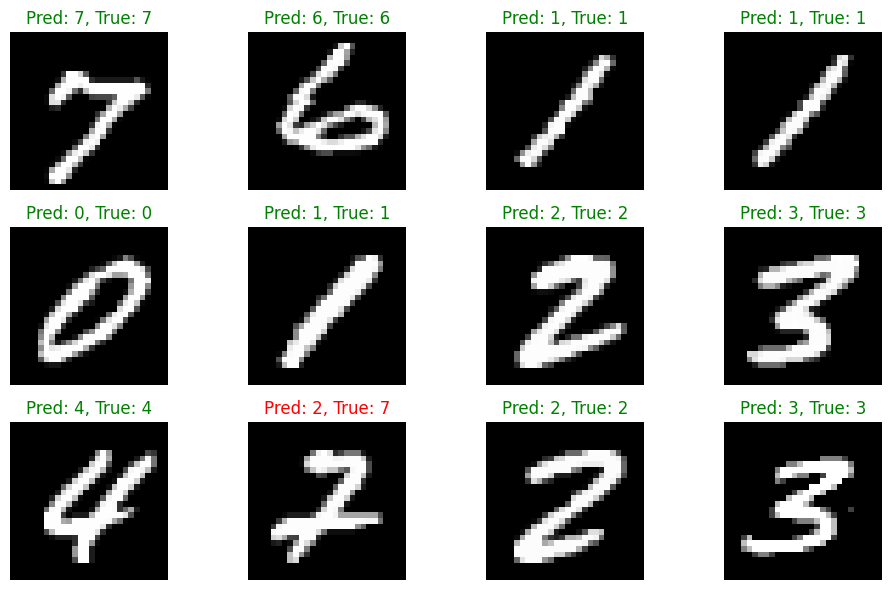

In [ ]:
# plot first 12 images with predicted vs true label
plt.figure(figsize=(10,6))
for i in range(12):
    plt.subplot(3, 4, i+1)
    img = images[i].cpu().squeeze()  # remove channel dim, move to CPU
    plt.imshow(img, cmap="gray")
    pred = predicted[i].item()
    true = labels[i].item()
    color = "green" if pred == true else "red"
    plt.title(f"Pred: {pred}, True: {true}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()

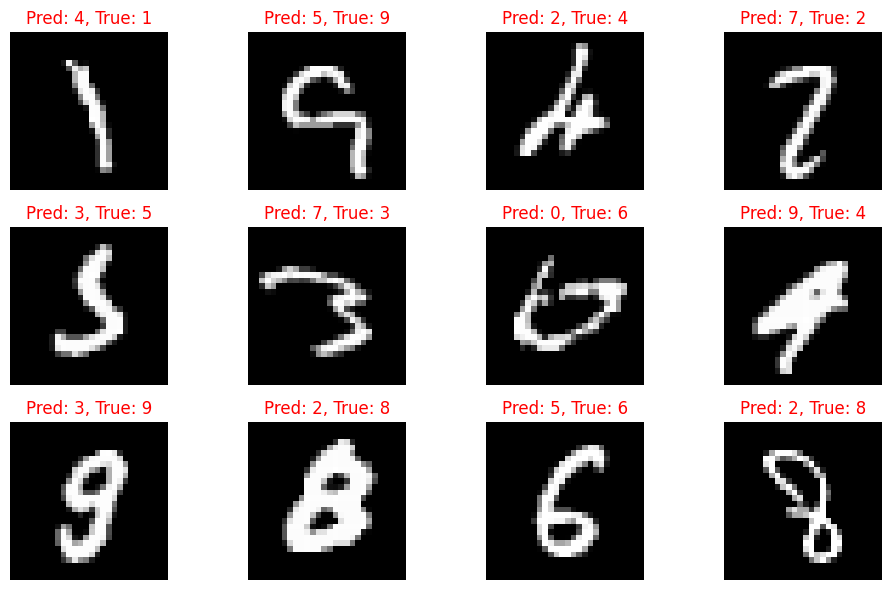

In [ ]:
model.eval()
misclassified = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        wrong_mask = predicted != labels
        for img, pred, true in zip(images[wrong_mask], predicted[wrong_mask], labels[wrong_mask]):
            misclassified.append((img.cpu(), pred.item(), true.item()))
        if len(misclassified) >= 12:
            break

plt.figure(figsize=(10,6))
for i, (img, pred, true) in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i+1)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"Pred: {pred}, True: {true}", color="red")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [22]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

# Convert the torchvision MNIST datasets into flat numpy arrays
X_train = train_dataset.data.numpy().reshape(len(train_dataset), -1) / 255.0  # flatten 28x28 -> 784, scale to [0,1]
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy().reshape(len(test_dataset), -1) / 255.0
y_test = test_dataset.targets.numpy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (60000, 784)
Test shape: (10000, 784)


In [24]:
knn = KNeighborsClassifier(n_neighbors=3)

start = time.time()
knn.fit(X_train, y_train)
print(f"k-NN training time: {time.time() - start:.2f}s")

start = time.time()
y_pred_knn = knn.predict(X_test)
print(f"k-NN prediction time: {time.time() - start:.2f}s")

knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"k-NN test accuracy: {knn_accuracy*100:.2f}%")

k-NN training time: 0.04s
k-NN prediction time: 32.23s
k-NN test accuracy: 97.05%
